In [1]:
from torchsummary import summary
import reinforcement
import models
import gymnasium as gym
import numpy as np
import torch
import ale_py
import time
import utils

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = 1)
s, _ = env.reset()

env.states = env.observation_space.shape[0]*4
env.actions = env.action_space.shape[0]

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-4, hidden_dims = [500, 400, 300, 200])
critic = models.TD3_critic((env.states+env.actions), 1, softmax=False, lr = 1e-3, hidden_dims = [500, 400, 300, 200])

device = "cuda"
actor.to(device)
critic.to(device)

rewards, steps, acc_steps, actor_loss, critic_loss, td_errors = reinforcement.train_tdddpg(env, actor, critic, BATCH_SIZE = 258, start_steps= 1000,
                gamma = 0.99, nframes = 4, buffer_size = 100000, episodes = 10000, verbose=1, checkpoint=0, alpha = 0.6, beta = 0.4)
#rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 100, verbose=1, checkpoint=999, BATCH_SIZE=0)


c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 0 finished with reward -112.20660400390625 in 43 steps and 0.012686 time, Total steps: 44
Actor loss: 0, Critic loss: 0, Total steps: 44
Episode 1 finished with reward -190.69024749162526 in 1207 steps and 4.125426 time, Total steps: 1252
Actor loss: 0.4894252965071549, Critic loss: 5.46183224632183, Total steps: 1252
Episode 2 finished with reward -121.90980383920146 in 88 steps and 1.252511 time, Total steps: 1341
Actor loss: 0.870685417091267, Critic loss: 31.317758872602763, Total steps: 1341
Episode 3 finished with reward -114.7219775212078 in 63 steps and 0.903240 time, Total steps: 1405
Actor loss: 1.6353172864764929, Critic loss: 49.51600544899702, Total steps: 1405
Episode 4 finished with reward -104.88586538193266 in 85 steps and 1.280818 time, Total steps: 1491
Actor loss: 1.0906257511571396, Critic loss: 36.51744719438775, Total steps: 1491
Episode 5 finished with reward -124.8450017302812 in 243 steps and 3.724850 time, Total steps: 1735
Actor loss: 0.9030202683672

-10.145465983734248 779.0113159335646


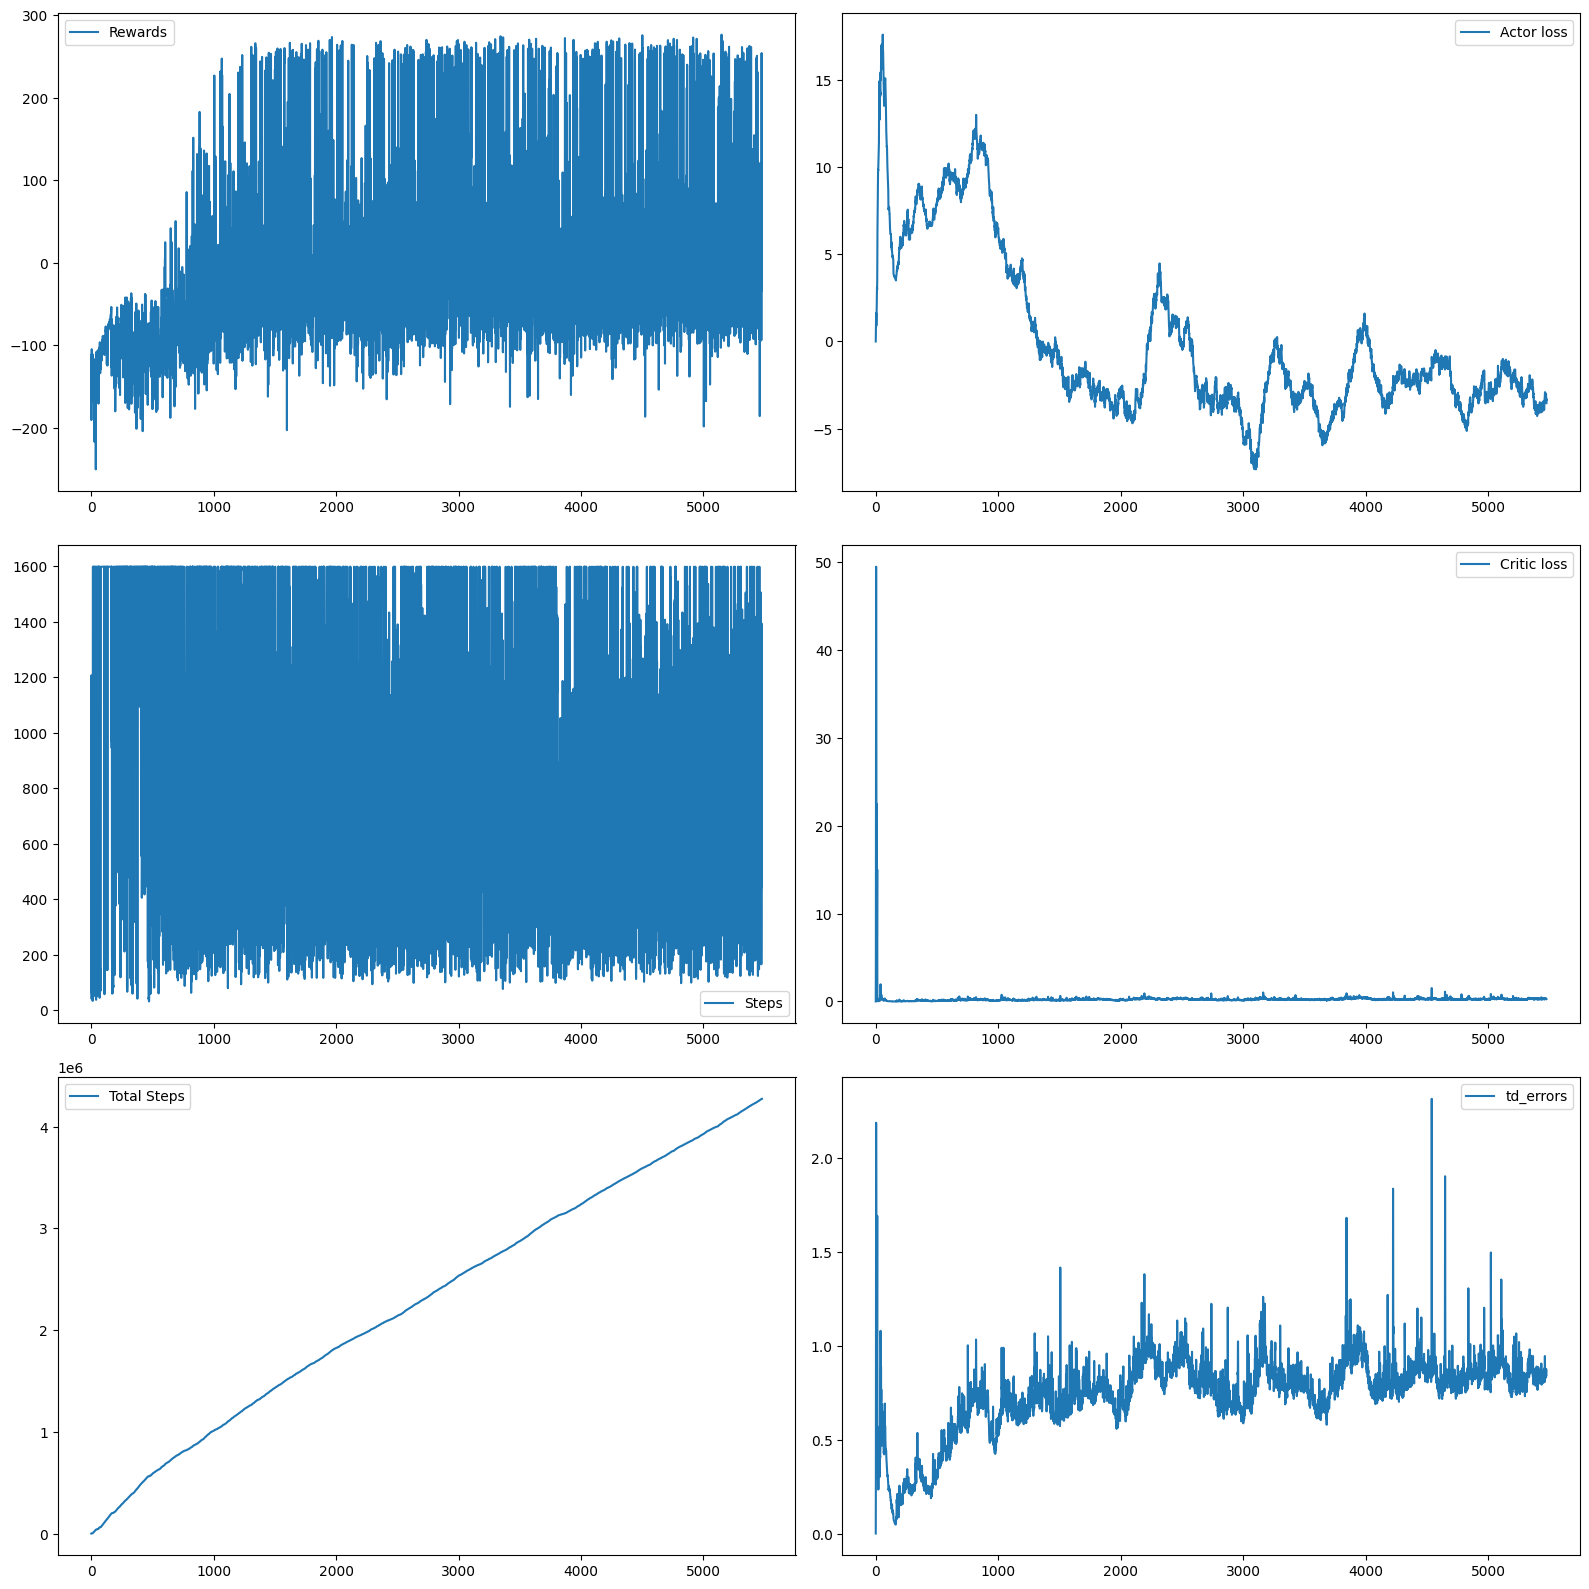

In [3]:
import matplotlib.pyplot as plt
## Plot the rewards, steps, and errors
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize=(16, 16))
ax[0,0].plot(rewards, label='Rewards')
ax[1,0].plot(steps, label='Steps')
ax[2,0].plot(acc_steps, label='Total Steps')  

ax[0,1].plot(actor_loss, label='Actor loss')  
ax[1,1].plot(critic_loss, label='Critic loss')  
ax[2,1].plot(td_errors, label='td_errors')  

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()

ax[0,1].legend()
ax[1,1].legend()
ax[2,1].legend()

print(np.mean(rewards), np.mean(steps))

plt.tight_layout()
plt.show()

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = 1)
s, _ = env.reset()

env.states = env.observation_space.shape[0]*4
env.actions = env.action_space.shape[0]

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-4, hidden_dims = [500, 400, 300, 200])
critic = models.TD3_critic((env.states+env.actions), 1, softmax=False, lr = 1e-3, hidden_dims = [500, 400, 300, 200])

device = "cuda"
actor.to(device)
critic.to(device)

rewards, steps, acc_steps, actor_loss, critic_loss, td_errors = reinforcement.train_tdddpg(env, actor, critic,
                gamma = 0.99, nframes = 4, buffer_size = 1000000, episodes = 5000, verbose=1, checkpoint=50, alpha = 0.6, beta = 0.4)
#rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 100, verbose=1, checkpoint=999, BATCH_SIZE=0)


Episode 0 finished with reward -99.92717742919922 in 64 steps and 0.018615 time, Total steps: 65
Actor loss: 0, Critic loss: 0, Total steps: 65
Episode 1 finished with reward -106.3537368774414 in 88 steps and 0.024268 time, Total steps: 154
Actor loss: 0, Critic loss: 0, Total steps: 154
Episode 2 finished with reward -100.06800079345703 in 88 steps and 0.027293 time, Total steps: 243
Actor loss: 0, Critic loss: 0, Total steps: 243
Episode 3 finished with reward -107.88291931152344 in 58 steps and 0.017091 time, Total steps: 302
Actor loss: 0, Critic loss: 0, Total steps: 302
Episode 4 finished with reward -189.2103993802454 in 1382 steps and 9.879009 time, Total steps: 1685
Actor loss: 0.7208030376387842, Critic loss: 5.659379765048392, Total steps: 1685
Episode 5 finished with reward -102.39753593143847 in 122 steps and 1.812793 time, Total steps: 1808
Actor loss: 1.514356789041738, Critic loss: 10.359604804011864, Total steps: 1808
Episode 6 finished with reward -121.65522981014914

In [ ]:
import importlib
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\hss19\\Documents\\GitHub\\ml-2025\\mlc\\reinforcement\\utils.py'>

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = 1, render_mode = "rgb_array")

actor.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/2025-06-28_11;24;45/models/actor_ep800.pth"))
critic.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/2025-06-28_11;24;45/models/critic_ep800.pth"))

#video_folder = "agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/videos"
video_folder = "temp/"
utils.record_model(env, actor, video_folder, "ep1000", nframes = 4)

Episode finished. Total reward: -48.876380920410156
